# House Price Prediction — Machine Learning Notebook

This notebook completes the **machine-learning / notebook portion** of the House Price Prediction assignment.

It includes:
- data loading and inspection
- data cleaning
- feature engineering
- exploratory data analysis (EDA)
- outlier handling
- high-cardinality categorical handling
- preprocessing with a scikit-learn Pipeline
- at least two regression models
- test-set MAE, RMSE, and R²
- model comparison
- actual-vs-predicted visualization
- 5-fold cross-validation
- feature importance
- final model export
- export of the allowed-location list

**Backend and frontend are intentionally excluded, as requested.**

## 1. Imports and configuration

The notebook uses pandas/numpy for data work, matplotlib/seaborn for EDA, and scikit-learn for preprocessing, modelling, and evaluation.

In [1]:
import os
import re
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

## 2. Load the dataset

The assignment uses the Kaggle **House Price by Juhi Bhojani** dataset. The CSV should be placed in the same working folder as this notebook, or the path below can be changed.

Before doing any cleaning, we verify the actual columns in the downloaded file.

In [2]:
DATA_PATH = "house_prices.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (187531, 21)

Column names:
['Index', 'Title', 'Description', 'Amount(in rupees)', 'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area', 'Dimensions', 'Plot Area']


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


## 3. Initial data inspection

We inspect:
- number of rows and columns
- data types
- missing values
- duplicate rows
- descriptive statistics

This tells us what problems need to be handled before modelling.

In [3]:
print("Dataset shape:", df.shape)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)
display(missing)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNumeric summary:")
display(df.describe(include="all").T.head(30))

Dataset shape: (187531, 21)

Data types:


,dtype
Index,int64
Title,object
Description,object
Amount(in rupees),object
Price (in rupees),float64
location,object
Carpet Area,object
Status,object
Floor,object
Transaction,object



Missing values:


,missing_count,missing_percent
Plot Area,187531,100.00
Dimensions,187531,100.00
Society,109678,58.49
Super Area,107685,57.42
Car Parking,103357,55.11
overlooking,81436,43.43
Carpet Area,80673,43.02
facing,70233,37.45
Ownership,65517,34.94
Balcony,48935,26.09



Duplicate rows: 0

Numeric summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Target definition and cleaning helpers

The prediction target is **Amount(in rupees)**.

The raw target contains text such as `42 Lac`, `1.2 Cr`, and sometimes unusable values such as `Call for Price`.

The assignment specifies:
- 1 Lac = 100,000 rupees
- 1 Cr = 10,000,000 rupees

We also create helpers for area, BHK, floor, and numeric property fields.

In [4]:
TARGET = "Amount(in rupees)"

def parse_money(value):
    if pd.isna(value):
        return np.nan

    s = str(value).strip().lower()
    s = s.replace(",", "").replace("₹", "").strip()

    if s in {"", "nan", "none", "call for price", "contact for price"}:
        return np.nan

    try:
        if "cr" in s:
            number = re.sub(r"[^0-9.\-]", "", s.replace("cr", ""))
            return float(number) * 1e7

        if "lac" in s or "lakh" in s:
            number = s.replace("lac", "").replace("lakh", "")
            number = re.sub(r"[^0-9.\-]", "", number)
            return float(number) * 1e5

        number = re.sub(r"[^0-9.\-]", "", s)
        return float(number)

    except (ValueError, TypeError):
        return np.nan


def parse_area_sqft(value):
    """Convert sqft/sq.m values to sqft."""
    if pd.isna(value):
        return np.nan

    s = str(value).strip().lower().replace(",", "")

    match = re.search(r"([0-9]+(?:\.[0-9]+)?)", s)
    if not match:
        return np.nan

    number = float(match.group(1))

    # 1 square metre ≈ 10.764 square feet
    if "sqm" in s or "sq m" in s or "m²" in s or "meter" in s or "metre" in s:
        return number * 10.764

    return number


def parse_bhk(title):
    if pd.isna(title):
        return np.nan

    match = re.search(r"(\d+)\s*BHK", str(title), flags=re.I)
    return float(match.group(1)) if match else np.nan


def parse_floor(value):
    """Return floor number and total floors."""
    if pd.isna(value):
        return pd.Series([np.nan, np.nan])

    s = str(value).strip().lower()

    if "basement" in s:
        return pd.Series([-1.0, np.nan])

    if "ground" in s:
        total = re.search(r"out of\s*(\d+)", s)
        return pd.Series([0.0, float(total.group(1)) if total else np.nan])

    match = re.search(r"(\d+)\s*out of\s*(\d+)", s)
    if match:
        return pd.Series([float(match.group(1)), float(match.group(2))])

    match = re.search(r"^\s*(\d+)\s*$", s)
    if match:
        return pd.Series([float(match.group(1)), np.nan])

    return pd.Series([np.nan, np.nan])


def parse_numeric(value):
    if pd.isna(value):
        return np.nan

    match = re.search(r"(-?\d+(?:\.\d+)?)", str(value).replace(",", ""))
    return float(match.group(1)) if match else np.nan

## 5. Apply cleaning and feature engineering

We now:
1. convert the target price to a numeric value
2. remove rows with no usable target
3. convert carpet/super area to sqft
4. extract BHK from the title
5. extract floor number and total floors
6. convert bathroom/balcony/parking to numeric
7. remove exact duplicate rows

In [5]:
work = df.copy()

# Target
work["target_price"] = work[TARGET].apply(parse_money)
work = work.dropna(subset=["target_price"]).copy()

# Areas
if "Carpet Area" in work.columns:
    work["carpet_area_sqft"] = work["Carpet Area"].apply(parse_area_sqft)
else:
    work["carpet_area_sqft"] = np.nan

if "Super Area" in work.columns:
    work["super_area_sqft"] = work["Super Area"].apply(parse_area_sqft)
else:
    work["super_area_sqft"] = np.nan

# BHK
if "Title" in work.columns:
    work["bhk"] = work["Title"].apply(parse_bhk)
else:
    work["bhk"] = np.nan

# Floor
if "Floor" in work.columns:
    work[["floor_number", "total_floors"]] = work["Floor"].apply(parse_floor)
else:
    work["floor_number"] = np.nan
    work["total_floors"] = np.nan

# Numeric property fields
for source, target in [
    ("Bathroom", "bathroom_num"),
    ("Balcony", "balcony_num"),
    ("Car Parking", "parking_num")
]:
    if source in work.columns:
        work[target] = work[source].apply(parse_numeric)
    else:
        work[target] = np.nan

# Remove exact duplicate rows
work = work.drop_duplicates().copy()

print("Rows after basic cleaning:", len(work))
display(work[[
    "target_price",
    "carpet_area_sqft",
    "super_area_sqft",
    "bhk",
    "floor_number",
    "total_floors",
    "bathroom_num",
    "balcony_num",
    "parking_num"
]].head())

Rows after basic cleaning: 177847


,target_price,carpet_area_sqft,super_area_sqft,bhk,floor_number,total_floors,bathroom_num,balcony_num,parking_num
0,4200000.0,500.0,NaN,1.0,10.0,11.0,1.0,2.0,NaN
1,9800000.0,473.0,NaN,2.0,3.0,22.0,2.0,NaN,1.0
2,14000000.0,779.0,NaN,2.0,10.0,29.0,2.0,NaN,1.0
3,2500000.0,530.0,NaN,1.0,1.0,3.0,1.0,1.0,NaN
4,16000000.0,635.0,NaN,2.0,20.0,42.0,2.0,NaN,1.0


## 6. Exploratory Data Analysis (EDA)

The assignment requires at least four meaningful plots with written interpretation.

We produce:
1. target-price distribution
2. price vs carpet area
3. average price by the top 15 locations
4. price by furnishing status
5. an additional price-vs-bathroom boxplot
6. a correlation heatmap as an extra diagnostic

### 6.1 Target price distribution

House prices are usually strongly right-skewed. We show both the ordinary distribution and a log-transformed view to make the shape easier to inspect.

,target_price
count,1.778470e+05
mean,1.198134e+07
std,3.943827e+07
min,1.000000e+05
25%,4.840000e+06
50%,7.800000e+06
75%,1.450000e+07
max,1.400300e+10


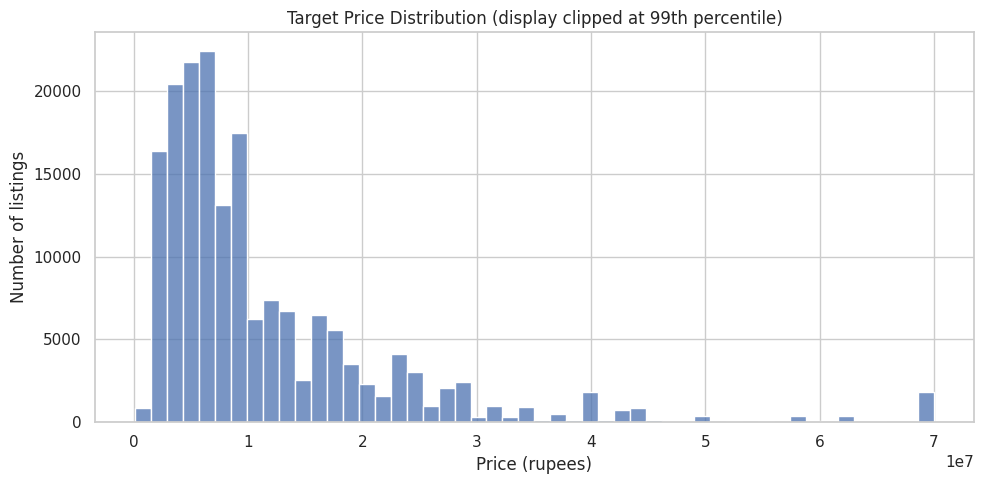

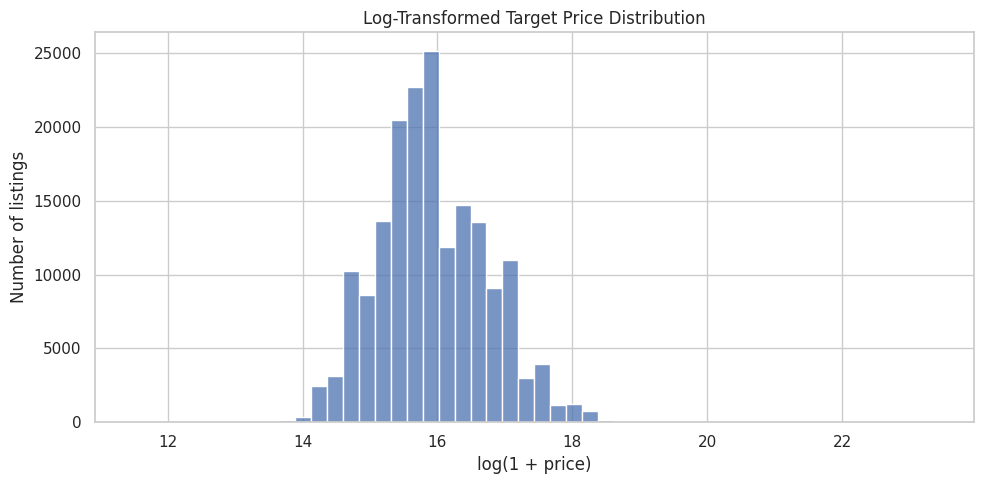

Interpretation: The price distribution is inspected on both the original and log scales because property prices are typically highly right-skewed.


In [6]:
display(work["target_price"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(
    work["target_price"].clip(upper=work["target_price"].quantile(0.99)),
    bins=50
)
plt.title("Target Price Distribution (display clipped at 99th percentile)")
plt.xlabel("Price (rupees)")
plt.ylabel("Number of listings")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(work["target_price"]), bins=50)
plt.title("Log-Transformed Target Price Distribution")
plt.xlabel("log(1 + price)")
plt.ylabel("Number of listings")
plt.tight_layout()
plt.show()

print(
    "Interpretation: The price distribution is inspected on both the original and log scales "
    "because property prices are typically highly right-skewed."
)

### 6.2 Price vs carpet area

This scatter plot checks whether larger carpet area is associated with higher listing prices.

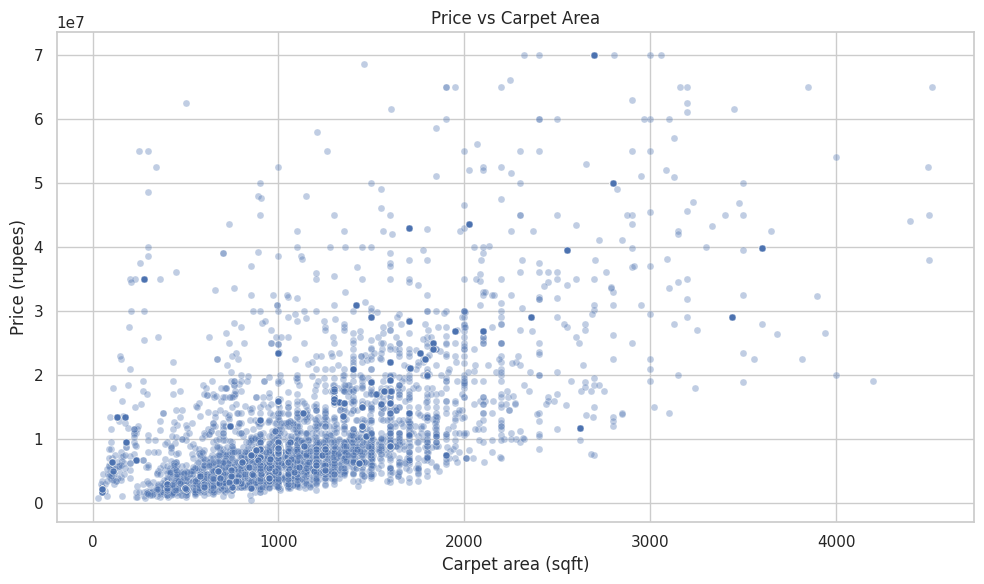

Interpretation: The plot helps us inspect the relationship between usable property area and listing price and also reveals extreme observations.


In [7]:
eda_area = work.dropna(subset=["carpet_area_sqft", "target_price"]).copy()

# Restrict only the visualization to the 99th percentiles so extreme points do not hide the pattern.
eda_area = eda_area[
    (eda_area["carpet_area_sqft"] <= eda_area["carpet_area_sqft"].quantile(0.99)) &
    (eda_area["target_price"] <= eda_area["target_price"].quantile(0.99))
]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=eda_area.sample(min(10000, len(eda_area)), random_state=RANDOM_STATE),
    x="carpet_area_sqft",
    y="target_price",
    alpha=0.35,
    s=25
)
plt.title("Price vs Carpet Area")
plt.xlabel("Carpet area (sqft)")
plt.ylabel("Price (rupees)")
plt.tight_layout()
plt.show()

print(
    "Interpretation: The plot helps us inspect the relationship between usable property area "
    "and listing price and also reveals extreme observations."
)

### 6.3 Average price by top 15 locations

The assignment asks for the **average price** of the top 15 locations, rather than simply counting how many listings each location has.

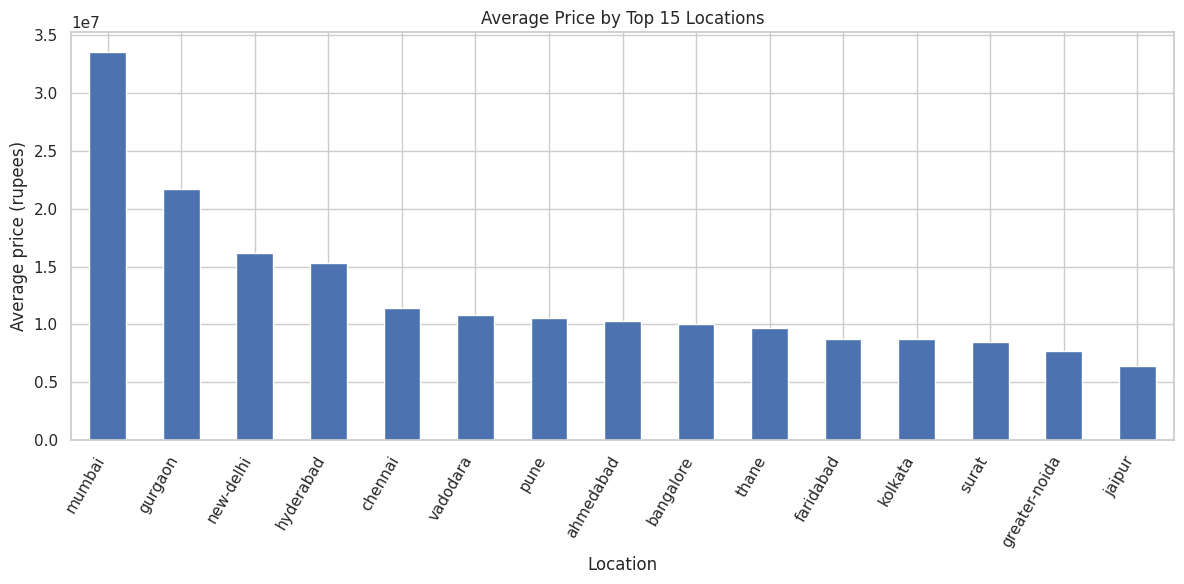

,average_price
location,
mumbai,3.355292e+07
gurgaon,2.170470e+07
new-delhi,1.616784e+07
hyderabad,1.526815e+07
chennai,1.139704e+07
vadodara,1.082852e+07
pune,1.052901e+07
ahmedabad,1.027555e+07
bangalore,1.006305e+07


Interpretation: The bars show how average listing prices differ across the 15 most frequently represented locations in the dataset.


In [8]:
top_locations = work["location"].value_counts().head(15).index

location_avg = (
    work[work["location"].isin(top_locations)]
    .groupby("location")["target_price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
location_avg.plot(kind="bar")
plt.title("Average Price by Top 15 Locations")
plt.xlabel("Location")
plt.ylabel("Average price (rupees)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

display(location_avg.to_frame("average_price"))

print(
    "Interpretation: The bars show how average listing prices differ across the 15 most frequently "
    "represented locations in the dataset."
)

### 6.4 Price by furnishing status

A boxplot lets us compare the distribution of prices for furnished, semi-furnished, and unfurnished properties.

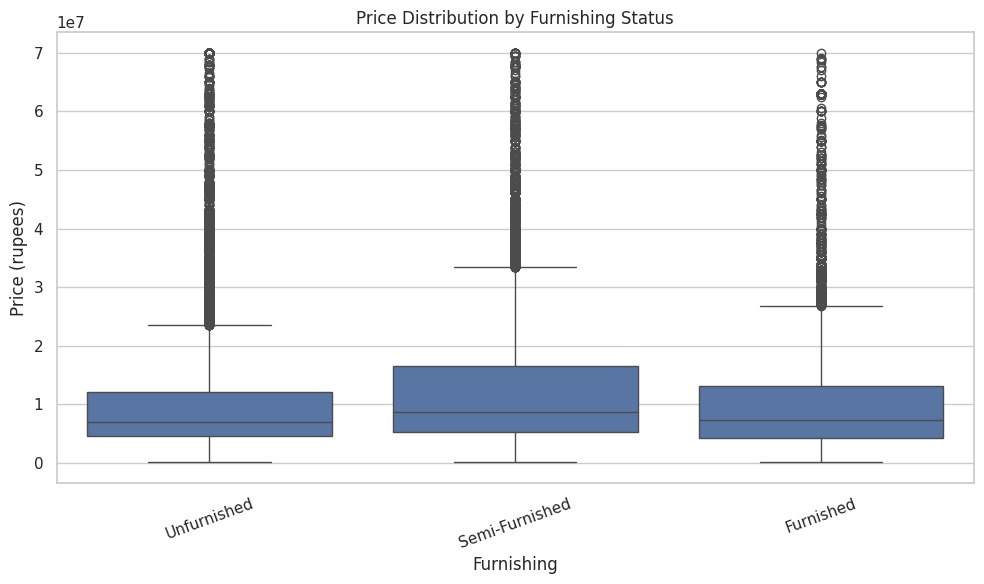

Interpretation: The boxplot compares the median, spread, and outliers of prices across furnishing categories.


In [9]:
if "Furnishing" in work.columns:
    furnishing_data = work.dropna(subset=["Furnishing", "target_price"]).copy()
    furnishing_data = furnishing_data[
        furnishing_data["target_price"] <= furnishing_data["target_price"].quantile(0.99)
    ]

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=furnishing_data, x="Furnishing", y="target_price")
    plt.title("Price Distribution by Furnishing Status")
    plt.xlabel("Furnishing")
    plt.ylabel("Price (rupees)")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    print(
        "Interpretation: The boxplot compares the median, spread, and outliers of prices "
        "across furnishing categories."
    )
else:
    print("Furnishing column is not available in this dataset.")

### 6.5 Price by number of bathrooms

This is an additional EDA plot required as an alternative/complement to the furnishing analysis.

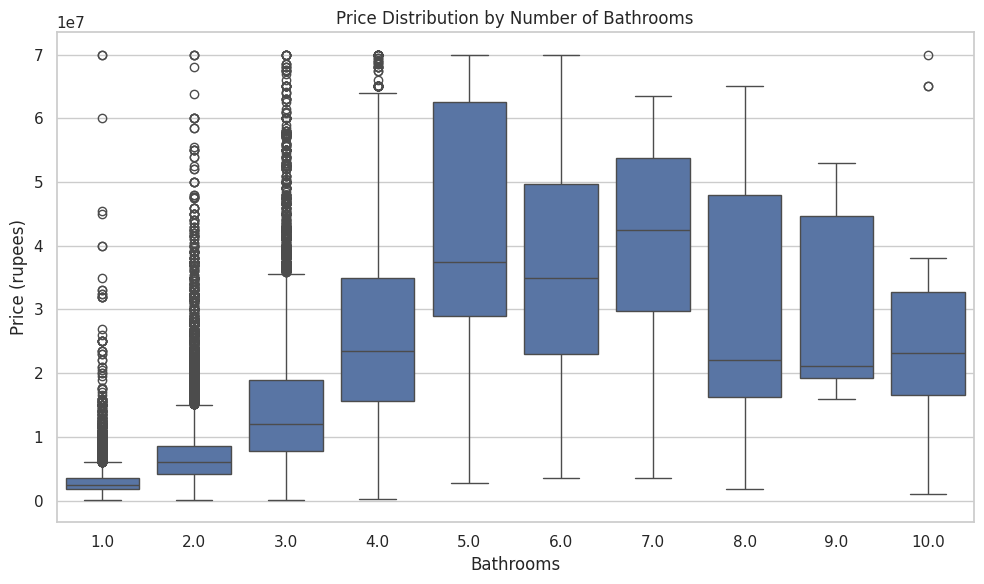

Interpretation: This plot checks how the price distribution changes as the number of bathrooms increases.


In [10]:
bath_data = work.dropna(subset=["bathroom_num", "target_price"]).copy()
bath_data = bath_data[
    bath_data["target_price"] <= bath_data["target_price"].quantile(0.99)
]

plt.figure(figsize=(10, 6))
sns.boxplot(data=bath_data, x="bathroom_num", y="target_price")
plt.title("Price Distribution by Number of Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Price (rupees)")
plt.tight_layout()
plt.show()

print(
    "Interpretation: This plot checks how the price distribution changes as the number "
    "of bathrooms increases."
)

### 6.6 Numeric correlation heatmap

This is an extra diagnostic plot. Correlation does not prove causation, but it helps identify potentially useful numeric relationships.

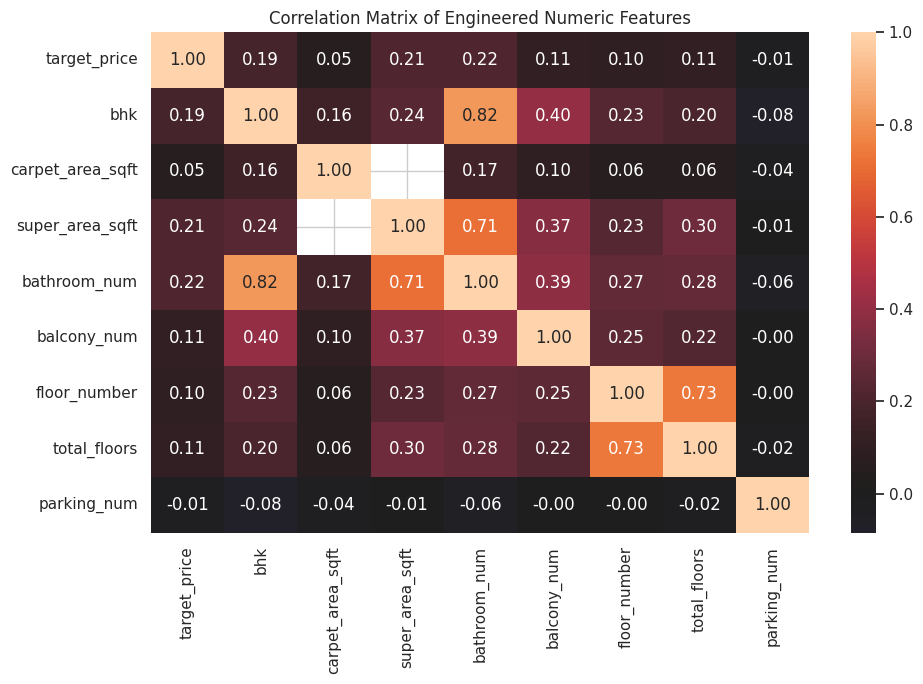

In [11]:
numeric_eda = [
    "target_price", "bhk", "carpet_area_sqft", "super_area_sqft",
    "bathroom_num", "balcony_num", "floor_number", "total_floors", "parking_num"
]

corr = work[numeric_eda].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", center=0)
plt.title("Correlation Matrix of Engineered Numeric Features")
plt.tight_layout()
plt.show()

## 7. High-cardinality handling

`location` and `Society` can contain many unique categorical values.

To avoid thousands of one-hot encoded categories, we:
- keep only the top 50 locations
- group all other locations into `Other`
- group Society values with fewer than 20 observations into `Other`

This follows the assignment's recommendation to handle high-cardinality categoricals before one-hot encoding.

In [12]:
TOP_N_LOCATIONS = 50

if "location" in work.columns:
    top_location_values = work["location"].value_counts().head(TOP_N_LOCATIONS).index
    work["location_grouped"] = work["location"].where(
        work["location"].isin(top_location_values),
        "Other"
    )
else:
    work["location_grouped"] = "Other"

if "Society" in work.columns:
    society_counts = work["Society"].value_counts(dropna=True)
    work["Society_grouped"] = work["Society"].where(
        work["Society"].map(society_counts).ge(20),
        "Other"
    )
else:
    work["Society_grouped"] = "Other"

print("Unique raw locations:", work["location"].nunique() if "location" in work.columns else 0)
print("Unique grouped locations:", work["location_grouped"].nunique())
print("Top grouped locations:")
display(work["location_grouped"].value_counts().head(10))

Unique raw locations: 81
Unique grouped locations: 51
Top grouped locations:


,count
location_grouped,
new-delhi,24945
bangalore,23262
kolkata,21605
gurgaon,18846
ahmedabad,12614
hyderabad,11147
chennai,10163
jaipur,7867
greater-noida,4490


## 8. Outlier handling using price per square foot

The assignment specifically recommends removing listings with implausible price-per-square-foot values.

We calculate:

`price_per_sqft = target_price / carpet_area_sqft`

and keep observations between the 1st and 99th percentiles.

Rows with missing/non-positive carpet area cannot produce a meaningful price-per-square-foot value, so they are not used for this outlier filter.

In [13]:
outlier_data = work.dropna(subset=["target_price", "carpet_area_sqft"]).copy()

outlier_data = outlier_data[outlier_data["carpet_area_sqft"] > 0].copy()

outlier_data["price_per_sqft"] = (
    outlier_data["target_price"] / outlier_data["carpet_area_sqft"]
)

lower_ppsf = outlier_data["price_per_sqft"].quantile(0.01)
upper_ppsf = outlier_data["price_per_sqft"].quantile(0.99)

before_outliers = len(outlier_data)

work = outlier_data[
    outlier_data["price_per_sqft"].between(lower_ppsf, upper_ppsf)
].copy()

print("Price/sqft lower bound:", lower_ppsf)
print("Price/sqft upper bound:", upper_ppsf)
print("Rows before outlier removal:", before_outliers)
print("Rows after outlier removal:", len(work))

Price/sqft lower bound: 2705.8823529411766
Price/sqft upper bound: 101503.75939849624
Rows before outlier removal: 101522
Rows after outlier removal: 99968


## 9. Final feature set

The raw `Price (in rupees)` field is excluded because it is itself a price-per-square-foot value and would create target leakage when predicting the total amount.

Raw free-text fields such as `Description` and `Title` are not directly fed into the tabular models. Useful information such as BHK is extracted from the title.

In [14]:
numeric_features = [
    "bhk",
    "carpet_area_sqft",
    "super_area_sqft",
    "floor_number",
    "total_floors",
    "bathroom_num",
    "balcony_num",
    "parking_num"
]

categorical_features = [
    "location_grouped",
    "Status",
    "Transaction",
    "Furnishing",
    "facing",
    "overlooking",
    "Ownership",
    "Society_grouped"
]

# Keep only columns that actually exist.
numeric_features = [c for c in numeric_features if c in work.columns]
categorical_features = [c for c in categorical_features if c in work.columns]

features = numeric_features + categorical_features

X = work[features].copy()
y = work["target_price"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Features used for modelling:")
print(features)
print("\nTraining shape:", X_train.shape)
print("Test shape:", X_test.shape)

Features used for modelling:
['bhk', 'carpet_area_sqft', 'super_area_sqft', 'floor_number', 'total_floors', 'bathroom_num', 'balcony_num', 'parking_num', 'location_grouped', 'Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Ownership', 'Society_grouped']

Training shape: (79974, 16)
Test shape: (19994, 16)


## 10. Preprocessing Pipeline

The preprocessing is bundled into a scikit-learn `Pipeline` so that:
- numeric missing values are imputed with the median
- numeric features are standardized
- categorical missing values are imputed with the most frequent category
- categorical variables are one-hot encoded
- unknown categories at inference time are ignored safely

This makes the exported model self-contained.

In [15]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

## 11. Model 1 — Linear Regression

Linear Regression is used as a baseline model.

In [16]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

def regression_report(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

results = pd.DataFrame([
    regression_report(y_test, linear_pred, "Linear Regression")
])

display(results)

,Model,MAE,RMSE,R2
0,Linear Regression,2.868757e+06,6.054048e+06,0.81799


## 12. Model 2 — Random Forest Regressor

Random Forest can capture non-linear relationships and interactions between housing characteristics.

In [18]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=2
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

results = pd.concat([
    results,
    pd.DataFrame([regression_report(y_test, rf_pred, "Random Forest")])
], ignore_index=True)

display(results.sort_values("R2", ascending=False).reset_index(drop=True))

,Model,MAE,RMSE,R2
0,Random Forest,1.007850e+06,3.848260e+06,0.926459
1,Linear Regression,2.868757e+06,6.054048e+06,0.817990


## 13. Model comparison and winner selection

The models are compared using the **test set**.

For MAE and RMSE, lower is better.
For R², higher is better.

We select the model with the best overall test performance rather than assuming a winner in advance.

In [19]:
comparison = results.sort_values(
    by=["R2", "RMSE", "MAE"],
    ascending=[False, True, True]
).reset_index(drop=True)

display(comparison)

winner_name = comparison.loc[0, "Model"]

if winner_name == "Linear Regression":
    winner_model = linear_model
    winner_pred = linear_pred
else:
    winner_model = rf_model
    winner_pred = rf_pred

print("Selected final model:", winner_name)

,Model,MAE,RMSE,R2
0,Random Forest,1.007850e+06,3.848260e+06,0.926459
1,Linear Regression,2.868757e+06,6.054048e+06,0.817990


Selected final model: Random Forest


## 14. Final test-set evaluation

These are the required test-set metrics for the selected model:
- MAE
- RMSE
- R²

In [20]:
final_metrics = pd.DataFrame([
    regression_report(y_test, winner_pred, winner_name)
])

display(final_metrics)

,Model,MAE,RMSE,R2
0,Random Forest,1.007850e+06,3.848260e+06,0.926459


## 15. Actual vs Predicted prices

A good regression model should place predictions reasonably close to the diagonal `Actual = Predicted` line.

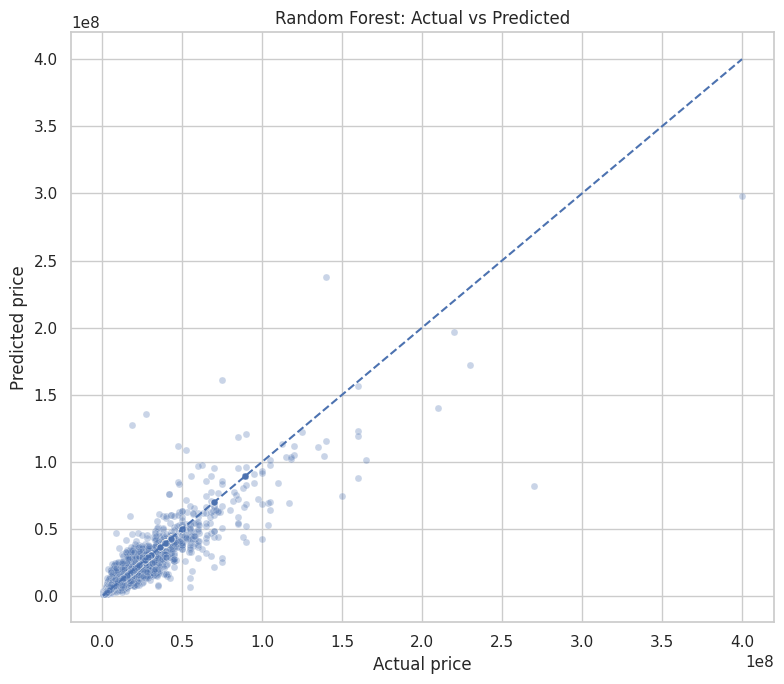

Interpretation: Points closer to the diagonal indicate predictions closer to the actual observed prices.


In [21]:
plt.figure(figsize=(8, 7))

sns.scatterplot(
    x=y_test,
    y=winner_pred,
    alpha=0.30,
    s=25
)

lims = [
    min(y_test.min(), winner_pred.min()),
    max(y_test.max(), winner_pred.max())
]

plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title(f"{winner_name}: Actual vs Predicted")
plt.tight_layout()
plt.show()

print(
    "Interpretation: Points closer to the diagonal indicate predictions closer to the "
    "actual observed prices."
)

## 16. 5-Fold Cross-Validation

Cross-validation is an additional stability check. It is run on a representative training sample to keep runtime practical on the large dataset.

In [22]:
CV_SAMPLE_SIZE = min(30000, len(X_train))

cv_idx = X_train.sample(
    CV_SAMPLE_SIZE,
    random_state=RANDOM_STATE
).index

X_cv = X_train.loc[cv_idx]
y_cv = y_train.loc[cv_idx]

cv_scores = cross_val_score(
    winner_model,
    X_cv,
    y_cv,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("5-Fold Cross-Validation R² scores:")
print(cv_scores)
print(f"Mean CV R²: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")

5-Fold Cross-Validation R² scores:
[0.84498468 0.91332863 0.90274031 0.90096072 0.76436433]
Mean CV R²: 0.8653
Standard deviation: 0.0558


## 17. Feature importance

Feature importance is shown for the Random Forest model when it is selected as the final model.

If Linear Regression wins, we show the absolute coefficients instead, because linear regression does not provide tree-style feature importance.

,importance
num__carpet_area_sqft,0.601183
num__total_floors,0.118935
cat__location_grouped_mumbai,0.056908
cat__location_grouped_new-delhi,0.018650
cat__Society_grouped_La Lagune Gurgaon,0.018320
num__balcony_num,0.017386
num__floor_number,0.017199
cat__Society_grouped_Hightown Residences,0.017002
num__parking_num,0.016396
num__bathroom_num,0.016196


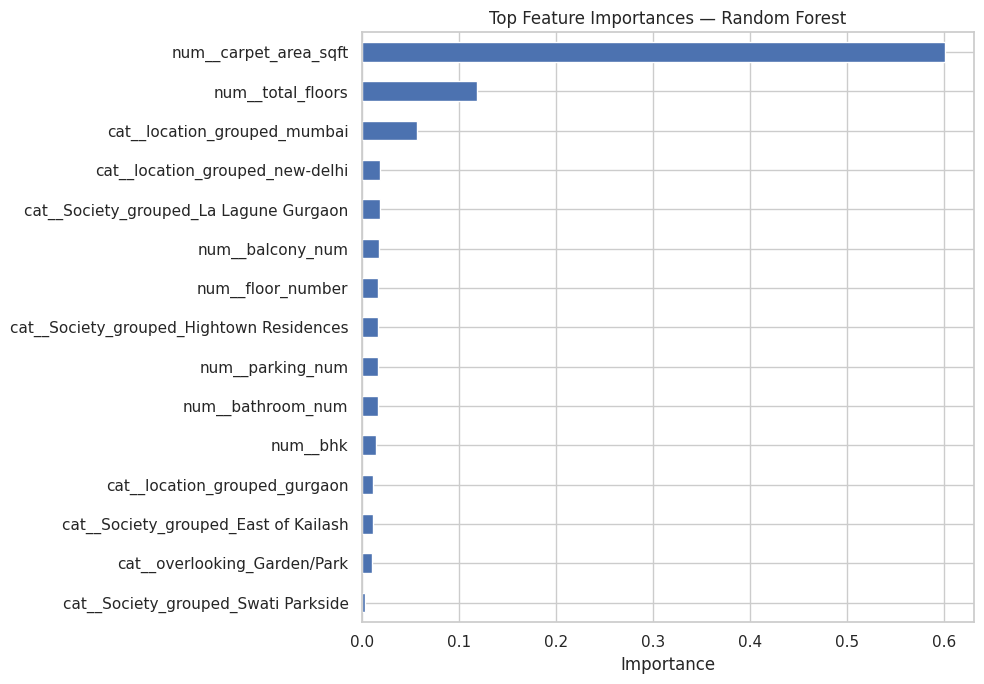

In [23]:
if winner_name == "Random Forest":
    fitted_preprocessor = winner_model.named_steps["preprocessor"]
    fitted_rf = winner_model.named_steps["model"]

    transformed_names = fitted_preprocessor.get_feature_names_out()
    importance = pd.Series(
        fitted_rf.feature_importances_,
        index=transformed_names
    ).sort_values(ascending=False)

    display(importance.head(20).to_frame("importance"))

    plt.figure(figsize=(10, 7))
    importance.head(15).sort_values().plot(kind="barh")
    plt.title("Top Feature Importances — Random Forest")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

else:
    fitted_preprocessor = winner_model.named_steps["preprocessor"]
    fitted_lr = winner_model.named_steps["model"]

    transformed_names = fitted_preprocessor.get_feature_names_out()
    coefficients = pd.Series(
        np.abs(fitted_lr.coef_),
        index=transformed_names
    ).sort_values(ascending=False)

    display(coefficients.head(20).to_frame("absolute_coefficient"))

    plt.figure(figsize=(10, 7))
    coefficients.head(15).sort_values().plot(kind="barh")
    plt.title("Top Absolute Coefficients — Linear Regression")
    plt.xlabel("Absolute coefficient")
    plt.tight_layout()
    plt.show()

## 18. Export the final model

The assignment requires exporting the trained model.

Because the preprocessing is inside the scikit-learn Pipeline, the exported `.pkl` file contains both preprocessing and the final estimator.

We also export the grouped location values for later use by the application.

In [24]:
MODEL_PATH = "house_price.pkl"
LOCATIONS_PATH = "locations.json"

joblib.dump(winner_model, MODEL_PATH)

allowed_locations = sorted(
    work["location_grouped"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

with open(LOCATIONS_PATH, "w", encoding="utf-8") as f:
    json.dump(allowed_locations, f, ensure_ascii=False, indent=2)

print("Saved model:", MODEL_PATH)
print("Saved locations:", LOCATIONS_PATH)

Saved model: house_price.pkl
Saved locations: locations.json


## 19. Reload and sanity-check the exported model

We reload the `.pkl` file and predict one test observation. This verifies that the exported Pipeline can be used independently of the current Python object.

In [25]:
loaded_model = joblib.load(MODEL_PATH)

sample = X_test.iloc[[0]]
sample_prediction = loaded_model.predict(sample)[0]

print("Sample actual price:", y_test.iloc[0])
print("Reloaded model prediction:", sample_prediction)

Sample actual price: 7500000.0
Reloaded model prediction: 7499314.07668855


## 20. Final conclusion

The notebook now covers the required machine-learning workflow:

- the raw dataset was inspected
- the target price was converted from text to numeric rupees
- area values were normalized to square feet
- floor, bathroom, balcony, parking, and BHK information were converted/extracted
- high-cardinality locations were grouped
- price-per-square-foot outliers were removed using the 1st/99th percentiles
- at least four required EDA plots were produced with interpretations
- two regression models were trained
- the models were compared using test-set MAE, RMSE, and R²
- actual-vs-predicted performance was visualized
- 5-fold cross-validation was included
- feature importance/coefficients were inspected
- the winning model was exported as `house_price.pkl`
- the allowed grouped locations were exported as `locations.json`

**Backend and frontend are intentionally not included in this notebook.**

# GitHub / Submission Checklist — Outside the Notebook

**Important:** GitHub is a separate phase in the official project guide. It is **not a modelling step and does not need to be embedded as Python code inside the notebook**.

The official guide requires a public GitHub repository with a clean history, no raw CSV, and a root README containing the project overview, architecture, tech stack, project structure, dataset/download instructions, setup information, model metrics, and screenshots. fileciteturn1file0L24-L30

For the version of the project requested here (Notebook only, with backend/frontend excluded), the GitHub folder can contain the notebook, README, and exported model files as appropriate.

### Recommended structure

```text
house-price-project/
│
├── notebooks/
│   └── house_price_assignment_modified.ipynb
│
├── models/
│   └── house_price.pkl
│
├── locations.json
├── README.md
├── .gitignore
└── requirements.txt
```

### Do NOT commit

```text
.venv/
__pycache__/
.env
*.log
house_prices.csv
```

The assignment specifically says not to commit the raw CSV. fileciteturn1file1L124-L129

### Git commands

After creating an empty GitHub repository:

```bash
git init
git add .
git commit -m "House price prediction: notebook and model"
git branch -M main
git remote add origin https://github.com/YOUR-USERNAME/YOUR-REPOSITORY.git
git push -u origin main
```

GitHub's official documentation recommends creating the remote repository and then adding the remote and pushing the local `main` branch. citeturn0search0turn0search5

### Final verification

Before submission:

1. Open the GitHub repository.
2. Confirm the notebook is visible.
3. Confirm `house_prices.csv` is NOT uploaded.
4. Confirm `house_price.pkl` is present if you intend to submit the model file.
5. Confirm `README.md` explains how to obtain the dataset and run the notebook.
6. Confirm the notebook runs top-to-bottom without errors.
7. Copy the public GitHub repository link for the submission form.

The official project guide requires each student to submit the GitHub repository link and says the repository must be accessible. fileciteturn1file2L185-L189

In [26]:
from google.colab import files
files.download("/content/house_price.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>